In [33]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import neurokit2 as nk
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt


In [34]:
# --- Configuración inicial ---
fs = 4  # Frecuencia de muestreo (cambia según tus datos)
window_duration = 60  # 1 minuto en segundos
window_size = window_duration * fs  # Puntos por ventana

In [48]:
# =====================================================================
# 1. LOAD REAL CSV DATA
# =====================================================================
# Replace with your actual file path and EDA column name
csv_file = '/mnt/c/Users/Elena/Documents/Bio-Workshop/Group_Signal_Processing/EDA_workshop_exercise/Data/Subjects/subject_01/EDA.csv' 

sampling_rate = 4  # e.g., 4 Hz if recorded with an Empatica wristband. 

df = pd.read_csv(csv_file)
raw_eda = df.to_numpy().squeeze()

# Drop any accidental NaNs at the end/start of the file
raw_eda = raw_eda[~np.isnan(raw_eda)]

# Create a time array in minutes for plotting
time_minutes = np.arange(len(raw_eda)) / (sampling_rate * 60)


In [49]:
# Clean the EDA signal
clean_neurokit, info_neurokit = nk.eda_process(raw_eda, sampling_rate=fs, method='neurokit') 
clean_eda = clean_neurokit['EDA_Clean']

# Compute Tonic and Phasic components of the signal
highpass = nk.eda_phasic(clean_eda, sampling_rate=fs, method='highpass') 
tonic, phasic = highpass["EDA_Tonic"].values, highpass["EDA_Phasic"].values

/home/elena/miniforge3/envs/dynapse_env/lib/python3.11/site-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [37]:
# Define the task periods 
task_mins = {
    'r1': (0, 3),   # Rest 1: 0-3 minutes
    't1': (3, 13),  # Task 1: 3-13 minutes
    'r2': (13, 15), # Rest 2: 13-15 minutes
    't2': (15, 20), # Task 2: 15-20 minutes
    'r3': (20, 22), # Rest 3: 20-22 minutes
    't3': (22, 25), # Task 3: 22-25 minutes
    'r4': (25, 27)  # Rest 4: 25-27 minutes
}

task_mins_positions = {
    'r1': (task_mins['r1'][0]*60*fs, task_mins['r1'][1]*60*fs), # Convert rest 1 period to samples
    't1': (task_mins['t1'][0]*60*fs, task_mins['t1'][1]*60*fs),  # Convert task 1 period to samples
    'r2': (task_mins['r2'][0]*60*fs, task_mins['r2'][1]*60*fs), # Convert rest 2 period to samples
    't2': (task_mins['t2'][0]*60*fs, task_mins['t2'][1]*60*fs), # Convert task 2 period to samples
    'r3': (task_mins['r3'][0]*60*fs, task_mins['r3'][1]*60*fs), # Convert rest 3 period to samples
    't3': (task_mins['t3'][0]*60*fs, task_mins['t3'][1]*60*fs), # Convert task 3 period to samples
    'r4': (task_mins['r4'][0]*60*fs, task_mins['r4'][1]*60*fs)  # Convert rest 4 period to samples
}

In [4]:
# Calculate estimated sampling rate dynamically if you don't know it exactly
# Assuming the file is roughly 26 minutes long (1560 seconds)
# Adjust total_duration_seconds if you know the exact recording time!
total_duration_seconds = 2230  # e.g., 8921 points / 4Hz = ~2230 seconds
sampling_rate = int(round(len(raw_eda) / total_duration_seconds))
if sampling_rate < 1: 
    sampling_rate = 4  # Fallback baseline

print(f"DEBUG: Processing array shape: {raw_eda.shape}")
print(f"DEBUG: Detected Sampling Rate: {sampling_rate} Hz")

# =====================================================================
# 2. SAFE FILTERING
# =====================================================================
def safe_butter_lowpass(data, cutoff_hz, fs, order=2):
    nyq = 0.5 * fs
    # Guardrail: Cutoff must be strictly less than the Nyquist frequency
    if cutoff_hz >= nyq:
        cutoff_hz = nyq * 0.5
        print(f"⚠️ Adjusted filter cutoff to {cutoff_hz} Hz to match Nyquist limits.")
        
    normal_cutoff = cutoff_hz / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Calculate padlen safely based on filter coefficients
    padlen = 3 * max(len(a), len(b))
    
    return filtfilt(b, a, data, padlen=padlen)

# Apply filter
filtered_eda = safe_butter_lowpass(raw_eda, cutoff_hz=1.0, fs=sampling_rate, order=2)

# =====================================================================
# 3. DECOMPOSITION & SPIKE ENCODING (Fixed for Low Sampling Rates)
# =====================================================================
# We bypass NeuroKit's internal filter by setting method="none" 
# because our 'filtered_eda' is already perfectly clean.
eda_signals, info = nk.eda_process(
    filtered_eda, 
    sampling_rate=sampling_rate, 
    method="neurokit"  # Change to "neurokit" or handle components directly
)

# Alternatively, if it still complains about the internal filter, 
# we extract the components directly using the high-performance cvxEDA approach:
try:
    # Try standard decomposition first
    tonic_component = eda_signals["EDA_Tonic"].values
    phasic_component = eda_signals["EDA_Phasic"].values
except (ValueError, KeyError):
    print("⚠️ Standard method failed due to sampling rate constraints. Switching to robust manual decomposition...")
    # Direct fallback using NeuroKit's underlying median-filter method (immune to frequency bugs)
    decomposed = nk.eda_phasic(filtered_eda, sampling_rate=sampling_rate, method="median")
    tonic_component = decomposed["EDA_Tonic"].values
    phasic_component = decomposed["EDA_Phasic"].values


DEBUG: Processing array shape: (10019,)
DEBUG: Detected Sampling Rate: 4 Hz


/home/elena/miniforge3/envs/dynapse_env/lib/python3.11/site-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [38]:
# =====================================================================
# 4. POWER SPECTRUM ANALYSIS — SEGMENTOS DE 2 MINUTOS
# =====================================================================
from scipy.signal import welch

def compute_power_spectrum(signal, fs, segment_label=""):
    """
    Calcula el espectro de potencias usando el método de Welch.
    
    Parameters:
        signal       : array con los datos (EDA filtrada, phasic, etc.)
        fs           : frecuencia de muestreo en Hz
        segment_label: etiqueta para el gráfico
    
    Returns:
        freqs : array de frecuencias (Hz)
        power : densidad espectral de potencia
    """
    # nperseg: ventana de 60s para buena resolución frecuencial
    nperseg = min(len(signal), fs * 60)
    
    freqs, power = welch(signal, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
    return freqs, power


def extract_segment(signal, fs, start_min, end_min):
    """
    Extrae un segmento de la señal entre start_min y end_min (en minutos).
    
    Parameters:
        signal    : array completo de la señal
        fs        : frecuencia de muestreo en Hz
        start_min : inicio del segmento en minutos
        end_min   : fin del segmento en minutos (el intervalo es de 2 minutos)
    
    Returns:
        segment : array con los datos del intervalo
    """
    start_idx = int(start_min * 60 * fs)
    end_idx   = int(end_min   * 60 * fs)
    end_idx   = min(end_idx, len(signal))  # ← esto faltaba

    if start_idx >= len(signal):
        print(f"⚠️ Segmento {start_min}-{end_min} min fuera del rango.")
        return None

    return signal[start_idx:end_idx]

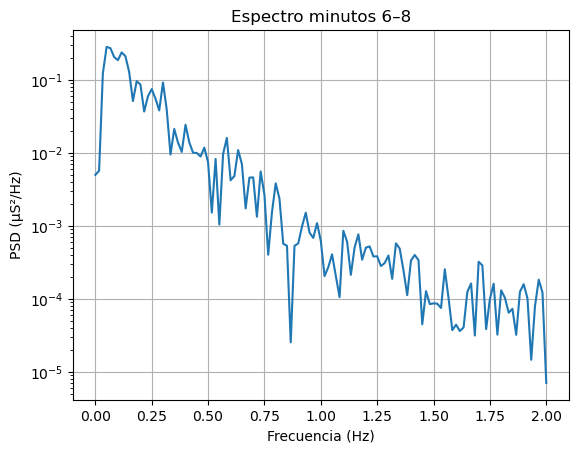

In [19]:
segments = [
    (13,  15,  "13-15 !st rest"),
    (20, 22, "2nd rest"),
    #(25, 27, "end"),  # ← así de simple
]
segment = extract_segment(phasic, fs, start_min=13, end_min=15)
freqs, power = compute_power_spectrum(segment, fs)
plt.semilogy(freqs, power)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("PSD (µS²/Hz)")
plt.title("Espectro minutos 6–8")
plt.grid(True)
plt.show()

In [39]:
decomposed = nk.eda_phasic(clean_eda, sampling_rate=fs, method='cvxeda')
tonic  = decomposed["EDA_Tonic"].values
phasic = decomposed["EDA_Phasic"].values

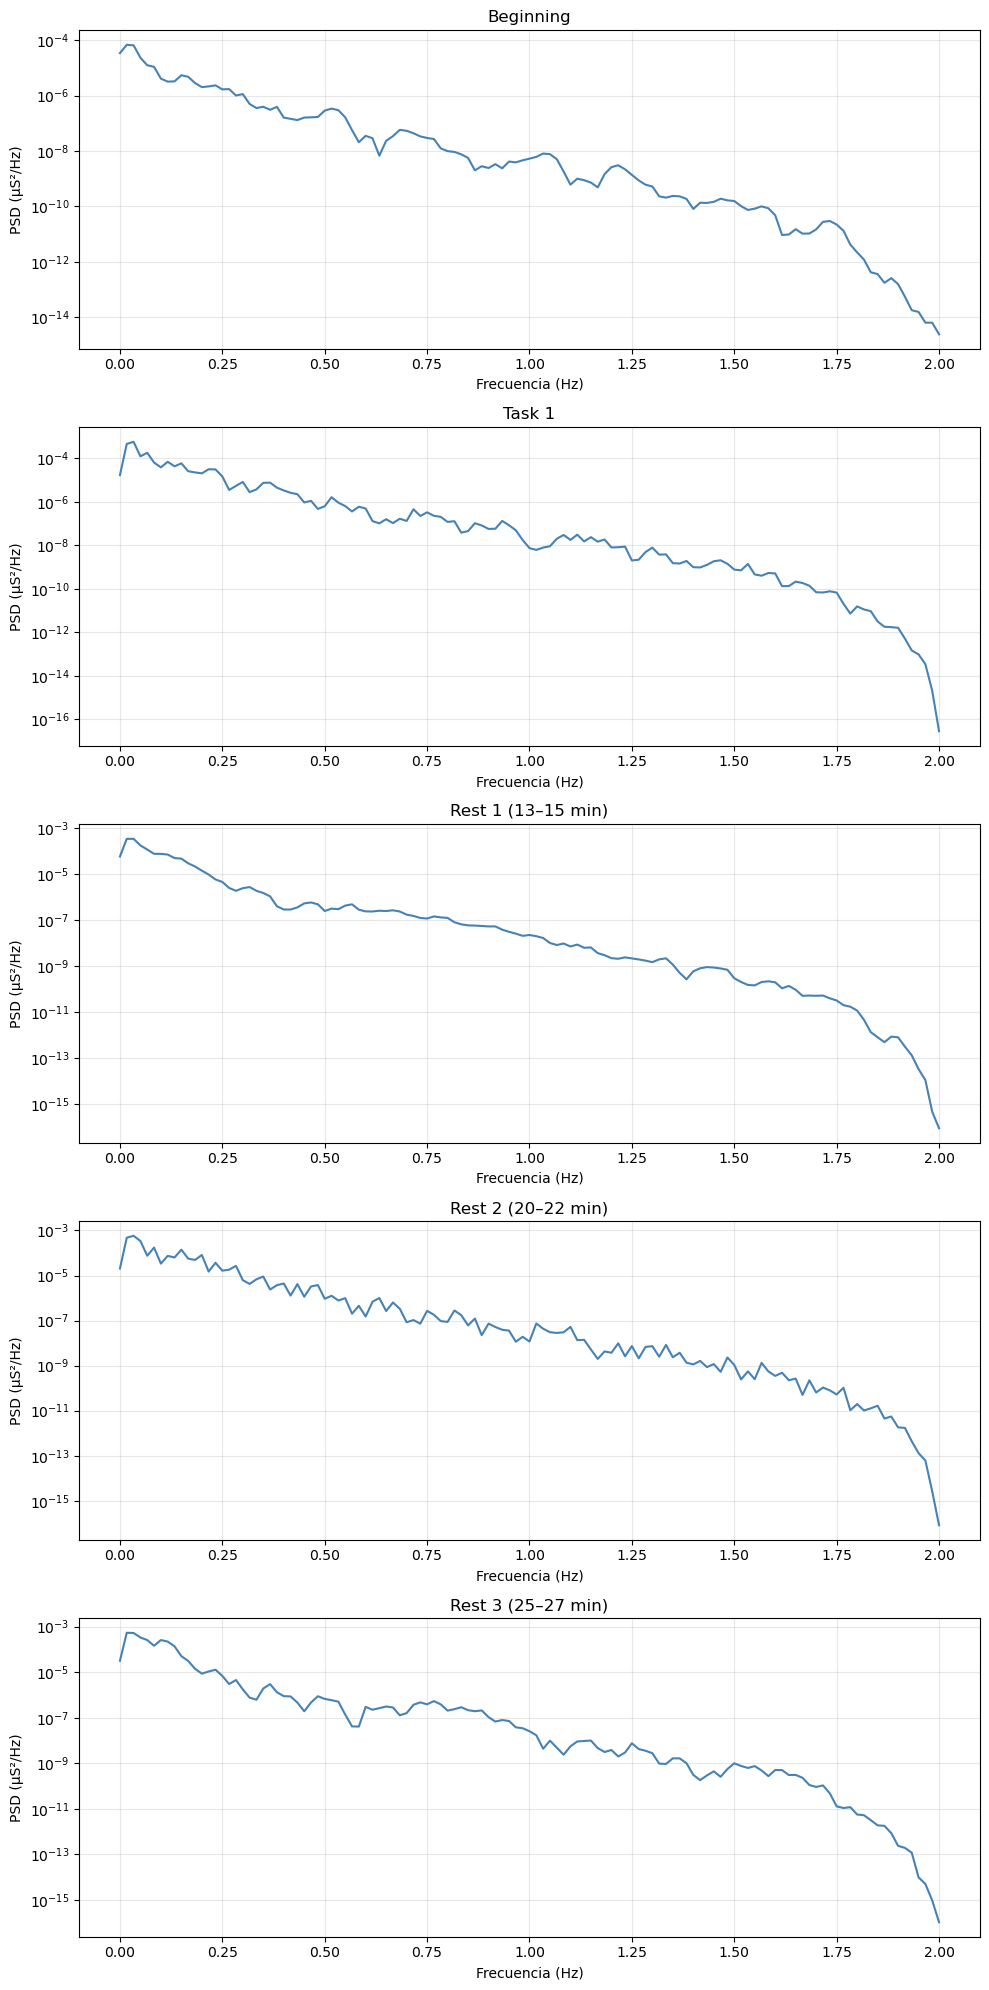

In [40]:
segments = [
    (0, 3,"Beginning"),
    (5,7,"Task 1"),
    (13, 15, "Rest 1 (13–15 min)"),
    (20, 22, "Rest 2 (20–22 min)"),
    (25, 27, "Rest 3 (25–27 min)"),
]

fig, axes = plt.subplots(len(segments), 1, figsize=(10, 4 * len(segments)))

for ax, (start, end, label) in zip(axes, segments):
    segment = extract_segment(phasic, fs, start, end)
    if segment is None:
        continue
    freqs, power = compute_power_spectrum(segment, fs)
    ax.semilogy(freqs, power, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("PSD (µS²/Hz)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Segment              SCR Band Power (0.045–0.25 Hz)
--------------------------------------------------
Beginning            0.000001 µS²
Task 1               0.000037 µS²
Task 2               0.000086 µS²
Task 3               0.000010 µS²
Rest 1               0.000010 µS²
Rest 2               0.000016 µS²
Rest 3               0.000022 µS²


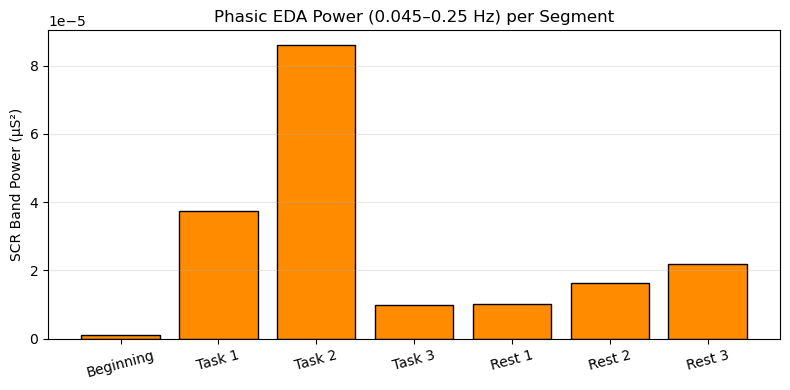

In [41]:
segments = [
    (0,  3,  "Beginning"),
    (6,  12, "Task 1"),
    (16,  18, "Task 2"),
    (23,  25, "Task 3"),
    (13, 15, "Rest 1"),
    (20, 22, "Rest 2"),
    (25, 27, "Rest 3"),
]

print(f"{'Segment':<20} {'SCR Band Power (0.045–0.25 Hz)'}")
print("-" * 50)

band_powers = {}
for start, end, label in segments:
    segment = extract_segment(phasic, fs, start, end)
    if segment is None:
        continue
    freqs, power = compute_power_spectrum(segment, fs)
    
    mask = (freqs >= 0.045) & (freqs <= 0.25)
    band_power = np.trapz(power[mask], freqs[mask])
    band_powers[label] = band_power
    print(f"{label:<20} {band_power:.6f} µS²")

# Bar chart for easy comparison
plt.figure(figsize=(8, 4))
plt.bar(band_powers.keys(), band_powers.values(), color='darkorange', edgecolor='black')
plt.ylabel("SCR Band Power (µS²)")
plt.title("Phasic EDA Power (0.045–0.25 Hz) per Segment")
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Segment              SCR Band Power (0–0.8 Hz)
--------------------------------------------------
Beginning            0.000004 µS²
Task 1               0.000112 µS²
Task 2               0.000135 µS²
Task 3               0.000017 µS²
Rest 1               0.000024 µS²
Rest 2               0.000039 µS²
Rest 3               0.000043 µS²


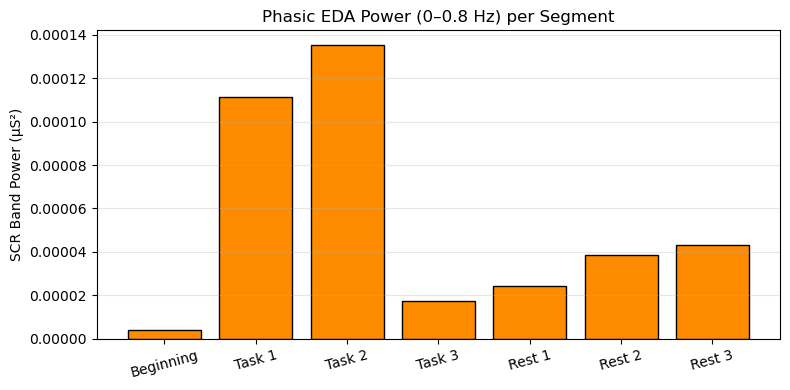

In [42]:
segments = [
    (0,  3,  "Beginning"),
    (6,  12, "Task 1"),
    (16,  18, "Task 2"),
    (23,  25, "Task 3"),
    (13, 15, "Rest 1"),
    (20, 22, "Rest 2"),
    (25, 27, "Rest 3"),
]

print(f"{'Segment':<20} {'SCR Band Power (0–0.8 Hz)'}")
print("-" * 50)

band_powers = {}
for start, end, label in segments:
    segment = extract_segment(phasic, fs, start, end)
    if segment is None:
        continue
    freqs, power = compute_power_spectrum(segment, fs)
    
    mask = (freqs >= 0) & (freqs <= 0.8)
    band_power = np.trapz(power[mask], freqs[mask])
    band_powers[label] = band_power
    print(f"{label:<20} {band_power:.6f} µS²")

# Bar chart for easy comparison
plt.figure(figsize=(8, 4))
plt.bar(band_powers.keys(), band_powers.values(), color='darkorange', edgecolor='black')
plt.ylabel("SCR Band Power (µS²)")
plt.title("Phasic EDA Power (0–0.8 Hz) per Segment")
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Segment              SCR (0.045–0.25)          Total (0–0.8)             Ratio
--------------------------------------------------------------------------------
Beginning            0.013765                  0.049193                  0.2798
Task 1               0.038079                  0.333803                  0.1141
Rest 1               0.098075                  0.518693                  0.1891
Rest 2               0.082799                  0.226583                  0.3654
Rest 3               0.018259                  0.091572                  0.1994


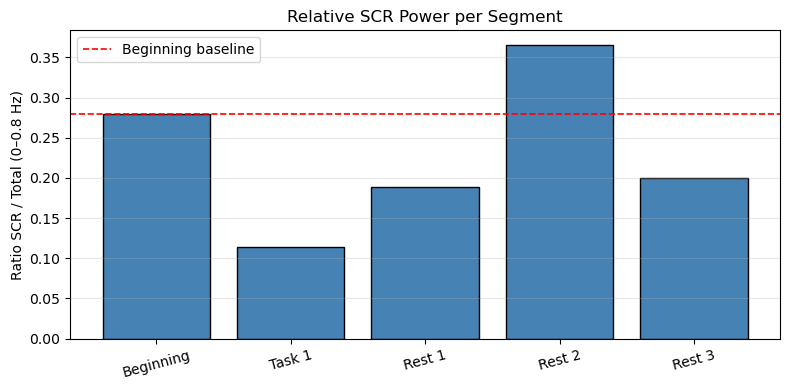

In [30]:
segments = [
    (0,  3,  "Beginning"),
    (3,  13, "Task 1"),
    (13, 15, "Rest 1"),
    (20, 22, "Rest 2"),
    (25, 27, "Rest 3"),
]

print(f"{'Segment':<20} {'SCR (0.045–0.25)':<25} {'Total (0–0.8)':<25} {'Ratio'}")
print("-" * 80)

ratios = {}
for start, end, label in segments:
    segment = extract_segment(phasic, fs, start, end)
    if segment is None:
        continue
    freqs, power = compute_power_spectrum(segment, fs)
    
    # Band 1: SCR band
    scr_mask   = (freqs >= 0.045) & (freqs <= 0.25)
    scr_power  = np.trapz(power[scr_mask], freqs[scr_mask])
    
    # Band 2: Total low-frequency band
    total_mask  = (freqs >= 0.0) & (freqs <= 0.8)
    total_power = np.trapz(power[total_mask], freqs[total_mask])
    
    # Ratio
    ratio = scr_power / total_power if total_power > 0 else np.nan
    ratios[label] = ratio
    
    print(f"{label:<20} {scr_power:<25.6f} {total_power:<25.6f} {ratio:.4f}")

# Bar chart
plt.figure(figsize=(8, 4))
plt.bar(ratios.keys(), ratios.values(), color='steelblue', edgecolor='black')
plt.ylabel("Ratio SCR / Total (0–0.8 Hz)")
plt.title("Relative SCR Power per Segment")
plt.axhline(y=ratios["Beginning"], color='red', linestyle='--', linewidth=1.2, label='Beginning baseline')
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Segment              Total (0–0.8 Hz)       EDASymp (0.045–0.25)      Ratio
--------------------------------------------------------------------------------
Beginning            0.000003               0.000001                  0.2815
Task 1               0.000086               0.000038                  0.4454
Task 2               0.000095               0.000047                  0.4988
Task 3               0.000024               0.000011                  0.4794
Rest 1               0.000018               0.000007                  0.4172
Rest 2               0.000041               0.000019                  0.4654
Rest 3               0.000039               0.000016                  0.4023


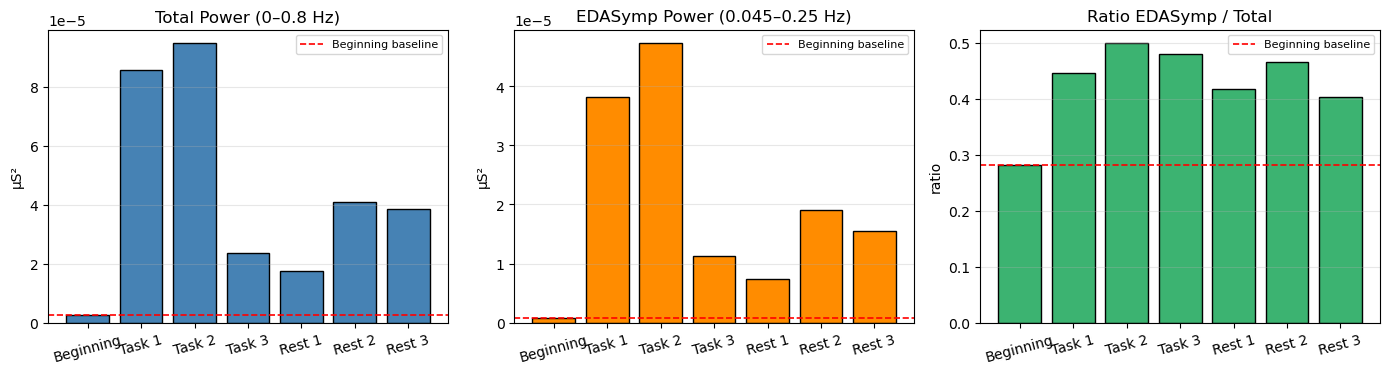

In [43]:
from scipy.signal import welch, butter, filtfilt
import numpy as np

def compute_psd_features(signal, fs_original=4, target_fs=4, 
                          window_sec=30, overlap=0.5):
    """
    Computes PSD features following the paper specification:
    - Low-pass filter at 0.8 Hz
    - Downsample to 4 Hz (already 4 Hz in your case)
    - Welch with 30s Hann window, 50% overlap
    - Features: total power (0–0.8 Hz) and EDASymp (0.045–0.25 Hz)
    """
    # Step 1: Low-pass filter at 0.8 Hz
    nyq = 0.5 * fs_original
    b, a = butter(2, 0.8 / nyq, btype='low')
    padlen = 3 * max(len(a), len(b))
    signal_filtered = filtfilt(b, a, signal, padlen=min(padlen, len(signal) - 1))

    # Step 2: Downsample to target_fs (no-op if already 4 Hz)
    if fs_original != target_fs:
        from scipy.signal import resample
        n_samples = int(len(signal_filtered) * target_fs / fs_original)
        signal_filtered = resample(signal_filtered, n_samples)
    fs = target_fs

    # Step 3: Welch PSD — 30s Hann window, 50% overlap
    nperseg = int(window_sec * fs)          # 30s * 4Hz = 120 samples
    noverlap = int(nperseg * overlap)       # 50% = 60 samples

    freqs, power = welch(signal_filtered, fs=fs,
                         window='hann',
                         nperseg=nperseg,
                         noverlap=noverlap)

    # Step 4: Extract features
    total_mask  = (freqs >= 0.0)    & (freqs <= 0.8)
    edasym_mask = (freqs >= 0.045)  & (freqs <= 0.25)

    total_power  = np.trapz(power[total_mask],  freqs[total_mask])
    edasym_power = np.trapz(power[edasym_mask], freqs[edasym_mask])
    ratio        = edasym_power / total_power if total_power > 0 else np.nan

    return freqs, power, total_power, edasym_power, ratio


# --- Run on all segments ---
segments = [
    (0,  3,  "Beginning"),
    (6,  12, "Task 1"),
    (16,  18, "Task 2"),
    (23,  25, "Task 3"),
    (13, 15, "Rest 1"),
    (20, 22, "Rest 2"),
    (25, 27, "Rest 3"),
]


print(f"{'Segment':<20} {'Total (0–0.8 Hz)':<22} {'EDASymp (0.045–0.25)':<25} {'Ratio'}")
print("-" * 80)

results = {}
for start, end, label in segments:
    segment = extract_segment(phasic, fs, start, end)
    if segment is None:
        continue

    freqs, power, total_power, edasym_power, ratio = compute_psd_features(segment, fs_original=fs)
    results[label] = {
        'total_power':  total_power,
        'edasym_power': edasym_power,
        'ratio':        ratio,
        'freqs':        freqs,
        'power':        power,
    }
    print(f"{label:<20} {total_power:<22.6f} {edasym_power:<25.6f} {ratio:.4f}")

# --- Bar chart: all three features ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = list(results.keys())

for ax, (feature, title, color) in zip(axes, [
    ('total_power',  'Total Power (0–0.8 Hz)',          'steelblue'),
    ('edasym_power', 'EDASymp Power (0.045–0.25 Hz)',   'darkorange'),
    ('ratio',        'Ratio EDASymp / Total',            'mediumseagreen'),
]):
    values = [results[l][feature] for l in labels]
    ax.bar(labels, values, color=color, edgecolor='black')
    ax.axhline(y=values[0], color='red', linestyle='--', linewidth=1.2, label='Beginning baseline')
    ax.set_title(title)
    ax.set_ylabel("µS²" if feature != 'ratio' else "ratio")
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
minutes_intervals = [(0,3,0), (3,13,1), (13,15,0), (15,20,1), (20,22,0), (22,25,1), (25,26,0)]
for start, end, label in minutes_intervals:
    data.iloc[start*60*fs : end*60*fs, data.columns.get_loc('state')] = label

# --- Extracción por Ventanas ---
features_list = []

num_windows = len(data) // window_size

KeyError: 'state'

In [15]:
for i in range(num_windows):
    window = data.iloc[i * window_size : (i + 1) * window_size]
    
    tonic_w = window['tonic'].values
    phasic_w = window['phasic'].values
    
    # Determinar la etiqueta de la ventana (por mayoría de votos)
    label = int(window['state'].mode()[0])
    
    # 1. Características Tónicas
    tonic_mean = np.mean(tonic_w)
    tonic_std = np.std(tonic_w)
    tonic_deriv = np.mean(np.diff(tonic_w)) # Tendencia (pendiente)
    
    # 2. Características Fásicas
    phasic_mean = np.mean(phasic_w)
    phasic_max = np.max(phasic_w)
    phasic_auc = np.sum(phasic_w) / fs # Área bajo la curva
    
    # Conteo de picos fásicos (SCRs)
    # Ajusta 'height' y 'distance' según la calidad de tu señal
    peaks, _ = find_peaks(phasic_w, height=0.05, distance=fs*1) 
    num_peaks = len(peaks)
    
    features_list.append({
        'window_id': i,
        'tonic_mean': tonic_mean,
        'tonic_std': tonic_std,
        'tonic_deriv': tonic_deriv,
        'phasic_mean': phasic_mean,
        'phasic_max': phasic_max,
        'phasic_auc': phasic_auc,
        'num_peaks': num_peaks,
        'label': label
    })

df_features = pd.DataFrame(features_list)
print(df_features.head())

NameError: name 'num_windows' is not defined